# 03 — Model Training
## Predictive Hospital Readmission Risk for Chronic Disease Patients

### Objective

Train and compare machine learning classification models for predicting:

> **Whether a patient will be readmitted within 30 days after discharge.**

### Input

The ML-ready data generated by:

`02_Preprocessing_Feature_Engineering.ipynb`

### Models

This notebook evaluates:

1. Dummy Baseline
2. Logistic Regression
3. Random Forest
4. XGBoost

### Training Strategy

- Training set → model fitting
- Validation set → model comparison and selection
- Test set → NOT used in this notebook

### Important

The final test set will be evaluated only in:

`04_Model_Evaluation.ipynb`

This prevents test-set information from influencing model selection.

## 1. Import Libraries

In [ ]:
from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import load, dump

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Import XGBoost

XGBoost is used as a third candidate model.

If the package is not installed, install it in the project environment:

```bash
pip install xgboost

In [2]:
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost is available.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not installed.")
    print("Install it using: pip install xgboost")
    

XGBoost is available.


## 3. Load Preprocessed ML Data

The data comes from:

`data/processed/model_data.pkl`

This file was generated by Notebook 02.

It contains:

- `X_train`
- `X_val`
- `X_test`
- `y_train`
- `y_val`
- `y_test`
- encoded feature names

In [3]:
DATA_PATH = Path("../data/processed/model_data.pkl")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Prepared data not found at:\n{DATA_PATH.resolve()}\n\n"
        "Run 02_Preprocessing_Feature_Engineering.ipynb first."
    )

prepared_data = load(DATA_PATH)

X_train = prepared_data["X_train"]
X_val = prepared_data["X_val"]
X_test = prepared_data["X_test"]

y_train = prepared_data["y_train"]
y_val = prepared_data["y_val"]
y_test = prepared_data["y_test"]

feature_names = prepared_data["feature_names"]

print("Prepared ML data loaded successfully.")

Prepared ML data loaded successfully.


In [4]:
print("Training shape   :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Test shape       :", X_test.shape)

print("\nTraining classes:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation classes:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest classes:")
print(pd.Series(y_test).value_counts().sort_index())

Training shape   : (61058, 141)
Validation shape : (20354, 141)
Test shape       : (20354, 141)

Training classes:
0    54244
1     6814
Name: count, dtype: int64

Validation classes:
0    18083
1     2271
Name: count, dtype: int64

Test classes:
0    18082
1     2272
Name: count, dtype: int64


## 4. Class Imbalance

Readmission within 30 days is the positive class:

`1 = Readmitted within 30 days`

The negative class is:

`0 = Not readmitted within 30 days`

Because the classes are imbalanced, the training models will use class-weighting or equivalent positive-class weighting where appropriate.

The test set is not used to calculate training weights.

In [5]:
train_class_counts = pd.Series(y_train).value_counts()

negative_count = train_class_counts.get(0, 0)
positive_count = train_class_counts.get(1, 0)

if positive_count == 0:
    raise ValueError("Training set contains no positive readmission cases.")

scale_pos_weight = negative_count / positive_count

print(f"Negative class count : {negative_count:,}")
print(f"Positive class count : {positive_count:,}")
print(f"XGBoost scale_pos_weight: {scale_pos_weight:.4f}")

Negative class count : 54,244
Positive class count : 6,814
XGBoost scale_pos_weight: 7.9607


## 5. Define Evaluation Function

Validation performance will be compared using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

### Why multiple metrics?

Accuracy alone can be misleading when the target classes are imbalanced.

Recall and F1-score are especially important for evaluating the positive readmission class.

ROC-AUC evaluates how well the model separates the two classes across probability thresholds.

In [7]:
def evaluate_model(model, X, y):
    """
    Evaluate a fitted binary classification model.

    Returns:
        dict containing validation metrics.
    """

    predictions = model.predict(X)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X)[:, 1]
    else:
        probabilities = None

    results = {
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(
            y,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y,
            predictions,
            zero_division=0
        )
    }

    if probabilities is not None:
        results["ROC-AUC"] = roc_auc_score(
            y,
            probabilities
        )
    else:
        results["ROC-AUC"] = np.nan

    return results

## 6. Train Baseline Model

Before using advanced models, we establish a simple baseline.

The baseline predicts the majority class for every patient.

A useful ML model should perform meaningfully better than this baseline.

In [8]:
baseline_model = DummyClassifier(
    strategy="prior"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_results = evaluate_model(
    baseline_model,
    X_val,
    y_val
)

baseline_results

{'Accuracy': 0.8884248796305394,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1 Score': 0.0,
 'ROC-AUC': 0.5}

## 7. Train Logistic Regression

Logistic Regression provides:

- a strong interpretable baseline
- probability estimates
- a linear decision boundary
- compatibility with sparse one-hot encoded data

Class weighting is used to give more importance to the minority positive class.

In [9]:
logistic_model = LogisticRegression(
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Training Logistic Regression...
Logistic Regression training completed.


In [10]:
logistic_results = evaluate_model(
    logistic_model,
    X_val,
    y_val
)

logistic_results

{'Accuracy': 0.5988994792178441,
 'Precision': 0.14968493639281893,
 'Recall': 0.5543813298106561,
 'F1 Score': 0.23572364725706796,
 'ROC-AUC': 0.6109042595870069}

## 8. Train Random Forest

Random Forest can model nonlinear relationships and interactions between features.

`class_weight="balanced_subsample"` helps compensate for the imbalanced target during tree construction.

In [11]:
random_forest_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [12]:
random_forest_results = evaluate_model(
    random_forest_model,
    X_val,
    y_val
)

random_forest_results

{'Accuracy': 0.8862631423798762,
 'Precision': 0.3103448275862069,
 'Recall': 0.015852047556142668,
 'F1 Score': 0.03016338500209468,
 'ROC-AUC': 0.6226360867970878}

## 9. Train XGBoost

XGBoost is a gradient-boosted tree classifier.

The positive-class weight is calculated only from the training data.

Parameters are kept moderate to reduce overfitting and training cost.

In [13]:
xgboost_model = None
xgboost_results = None

if XGBOOST_AVAILABLE:

    xgboost_model = XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=2,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )

    print("Training XGBoost...")

    xgboost_model.fit(
        X_train,
        y_train
    )

    print("XGBoost training completed.")

else:
    print("XGBoost training skipped because xgboost is not installed.")

Training XGBoost...
XGBoost training completed.


In [14]:
if xgboost_model is not None:

    xgboost_results = evaluate_model(
        xgboost_model,
        X_val,
        y_val
    )

    xgboost_results

## 10. Compare Validation Performance

The validation set is used to compare the candidate models.

The test set is still untouched.

In [15]:
results = [
    {
        "Model": "Dummy Baseline",
        **baseline_results
    },
    {
        "Model": "Logistic Regression",
        **logistic_results
    },
    {
        "Model": "Random Forest",
        **random_forest_results
    }
]

if xgboost_results is not None:
    results.append({
        "Model": "XGBoost",
        **xgboost_results
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.622384,0.156190,0.541612,0.242460,0.625568
1,Logistic Regression,0.598899,0.149685,0.554381,0.235724,0.610904
2,Random Forest,0.886263,0.310345,0.015852,0.030163,0.622636
3,Dummy Baseline,0.888425,0.000000,0.000000,0.000000,0.500000


## 11. Visualize Validation Performance

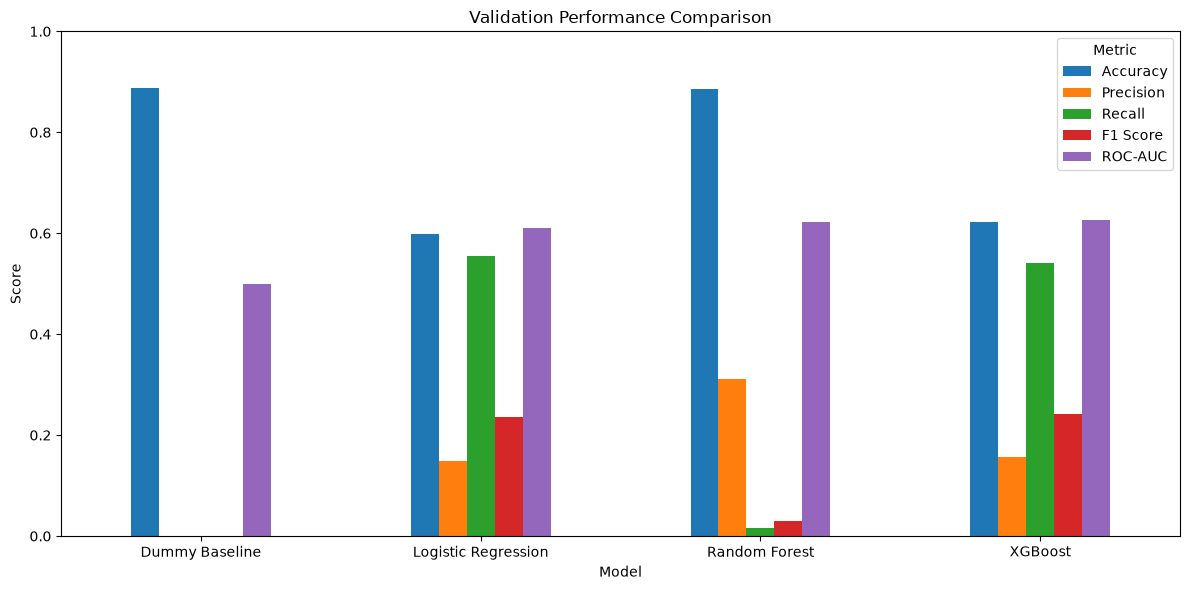

In [16]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

plot_df = results_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Validation Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 12. Select the Candidate Final Model

For this project, model selection will consider:

1. F1-score
2. Recall
3. ROC-AUC
4. Accuracy

The validation set is used for this decision.

The final test set remains untouched.

### Important

This is a **model-selection rule**, not a claim that one metric is universally the most important for clinical use. The final model will be evaluated comprehensively in Notebook 04.

In [17]:
# Sort primarily by F1 Score,
# then Recall,
# then ROC-AUC,
# then Accuracy.

selection_df = results_df.sort_values(
    by=[
        "F1 Score",
        "Recall",
        "ROC-AUC",
        "Accuracy"
    ],
    ascending=False
).reset_index(drop=True)

display(selection_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.622384,0.156190,0.541612,0.242460,0.625568
1,Logistic Regression,0.598899,0.149685,0.554381,0.235724,0.610904
2,Random Forest,0.886263,0.310345,0.015852,0.030163,0.622636
3,Dummy Baseline,0.888425,0.000000,0.000000,0.000000,0.500000


In [18]:
candidate_model_name = selection_df.loc[0, "Model"]

model_objects = {
    "Dummy Baseline": baseline_model,
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
}

if xgboost_model is not None:
    model_objects["XGBoost"] = xgboost_model

final_model = model_objects[candidate_model_name]

print(f"Candidate final model selected: {candidate_model_name}")

Candidate final model selected: XGBoost


## 13. Inspect Candidate Model Probability Predictions

The application needs a probability/risk value in addition to a binary prediction.

For example:

- Prediction = Readmitted within 30 days
- Probability = 0.72

This probability will later be used by the risk-reporting notebook and backend.

In [19]:
candidate_val_predictions = final_model.predict(X_val)

if not hasattr(final_model, "predict_proba"):
    raise RuntimeError(
        "Selected model does not support probability prediction."
    )

candidate_val_probabilities = final_model.predict_proba(X_val)[:, 1]

print("Example validation predictions:")

prediction_preview = pd.DataFrame({
    "Actual": y_val[:20],
    "Predicted": candidate_val_predictions[:20],
    "Readmission_Probability": (
        candidate_val_probabilities[:20] * 100
    ).round(2)
})

display(prediction_preview)

Example validation predictions:


,Actual,Predicted,Readmission_Probability
0,0,0,42.160000
1,0,0,49.900002
2,0,1,65.000000
3,0,0,48.599998
4,0,1,50.330002
5,0,1,60.230000
6,0,0,39.290001
7,0,0,39.439999
8,0,0,34.610001
9,0,0,22.379999


## 14. Analyze Probability Distribution

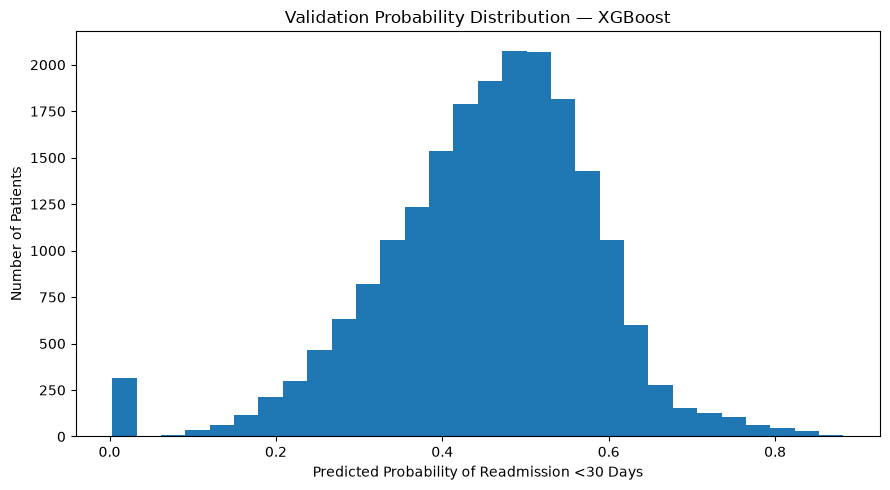

In [20]:
plt.figure(figsize=(9, 5))

plt.hist(
    candidate_val_probabilities,
    bins=30
)

plt.xlabel("Predicted Probability of Readmission <30 Days")
plt.ylabel("Number of Patients")
plt.title(f"Validation Probability Distribution — {candidate_model_name}")

plt.tight_layout()
plt.show()

## 15. Save the Candidate Final Model

The selected model is saved to:

`models/final_model.pkl`

The model is saved separately from the preprocessing object:

`models/preprocessor.pkl`

The backend will later load both.

### Prediction flow later

User input
→ preprocessor
→ final model
→ probability
→ risk report

In [21]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "final_model.pkl"

dump(
    final_model,
    MODEL_PATH,
    compress=3
)

print(f"Final model saved to:")
print(MODEL_PATH.resolve())

Final model saved to:
D:\hospital-readmission-project\ml-training\models\final_model.pkl


## 16. Save Training Metadata

Metadata records:

- selected model
- validation metrics
- model input features
- encoded feature count
- random seed
- project target definition

In [22]:

metadata = {
    "selected_model": candidate_model_name,
    "target": "readmitted_30",
    "target_definition": {
        "1": "Readmitted within 30 days",
        "0": "Not readmitted within 30 days"
    },
    "original_target_mapping": {
        "<30": 1,
        ">30": 0,
        "NO": 0
    },
    "final_input_features": prepared_data["final_features"],
    "encoded_feature_count": len(feature_names),
    "validation_metrics": {
        key: float(value)
        for key, value in selection_df[
            selection_df["Model"] == candidate_model_name
        ].iloc[0]
        .drop("Model")
        .items()
    },
    "random_state": 42
}

METADATA_PATH = MODEL_DIR / "model_metadata.json"

with open(METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(
        metadata,
        file,
        indent=4
    )

print(f"Metadata saved to:")
print(METADATA_PATH.resolve())

Metadata saved to:
D:\hospital-readmission-project\ml-training\models\model_metadata.json


## 17. Verify Saved Model

Reload the saved model and verify that it produces the same validation predictions.

In [23]:
loaded_model = load(MODEL_PATH)

loaded_predictions = loaded_model.predict(X_val)
loaded_probabilities = loaded_model.predict_proba(X_val)[:, 1]

predictions_match = np.array_equal(
    candidate_val_predictions,
    loaded_predictions
)

probabilities_match = np.allclose(
    candidate_val_probabilities,
    loaded_probabilities
)

print(f"Predictions match after reload : {predictions_match}")
print(f"Probabilities match after reload: {probabilities_match}")

if not predictions_match or not probabilities_match:
    raise RuntimeError("Saved model verification failed.")

print("\nSaved model verified successfully.")

Predictions match after reload : True
Probabilities match after reload: True

Saved model verified successfully.


# Training Summary

### Completed

- Loaded ML-ready data
- Established majority-class baseline
- Trained Logistic Regression
- Trained Random Forest
- Trained XGBoost
- Compared validation performance
- Selected a candidate final model
- Verified probability predictions
- Saved the final model
- Saved model metadata

### Important

The test set was not used for model selection.

### Generated files

`models/final_model.pkl`

`models/preprocessor.pkl`

`models/model_metadata.json`

### Next Notebook

`04_Model_Evaluation.ipynb`

The next notebook will perform the final evaluation on the untouched test set using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Classification Report
- Error analysis